# **Assignment 1 Deep Learning**

Linear Classification - Single Layer Perceptron on Iris Data

Balma Bahira Adzkia (25/572255/PPA/07189)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FILE_PATH = "Balma-572255-PMM-TemplateSLP.xlsx"
LEARNING_RATE = 0.1
INITIAL_BIAS = 0.5
INITIAL_WEIGHTS = np.array([0.5, 0.5, 0.5, 0.5], dtype=float)
THRESHOLD = 0.5


## **Data Prep**

**Data Train**

In [ ]:
raw = pd.read_excel(FILE_PATH, sheet_name="SLP-Training", header=None)

# Data Train
train = raw.iloc[4:, [0, 1, 2, 3, 4, 5, 6]].copy()
train.columns = ["epoch_label", "no", "X1", "X2", "X3", "X4", "TARGET"]

train = train[train["no"].notna()].copy()

train["epoch_label"] = train["epoch_label"].ffill()

feature_cols = ["X1", "X2", "X3", "X4"]
train[feature_cols + ["TARGET"]] = train[feature_cols + ["TARGET"]].apply(
    pd.to_numeric, errors="coerce"
)

train = train.dropna(subset=feature_cols + ["TARGET"]).reset_index(drop=True)

print("Jumlah baris training:", len(train))
display(train.head())
display(train.groupby("epoch_label").size())


Jumlah baris training: 400


,epoch_label,no,X1,X2,X3,X4,TARGET
0,epoch1,1,5.1,3.5,1.4,0.2,0
1,epoch1,2,4.9,3.0,1.4,0.2,0
2,epoch1,3,4.7,3.2,1.3,0.2,0
3,epoch1,4,4.6,3.1,1.5,0.2,0
4,epoch1,5,5.0,3.6,1.4,0.2,0


,0
epoch_label,
epoch 2,80
epoch 3,80
epoch 4,80
epoch 5,80
epoch1,80


**Data Validation**

In [ ]:
# Data Validation

val_raw = pd.read_excel(FILE_PATH, sheet_name="SLP-Validation", header=None)

val = val_raw.iloc[6:, [1, 2, 3, 4, 5, 6]].copy()
val.columns = ["no", "X1", "X2", "X3", "X4", "TARGET"]

val = val[val["no"].notna()].copy()

val[["no", "X1", "X2", "X3", "X4", "TARGET"]] = val[
    ["no", "X1", "X2", "X3", "X4", "TARGET"]
].apply(pd.to_numeric, errors="coerce")

val = val.dropna().reset_index(drop=True)

print("Jumlah data validation:", len(val))
display(val.head())

Jumlah data validation: 100


,no,X1,X2,X3,X4,TARGET
0,1,5.0,3.5,1.3,0.3,0
1,2,4.5,2.3,1.3,0.3,0
2,3,4.4,3.2,1.3,0.2,0
3,4,5.0,3.5,1.6,0.6,0
4,5,5.1,3.8,1.9,0.4,0


## **Training SLP**

In [ ]:
def sigmoid(z):
    # Clip untuk menghindari overflow pada exp
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

# Diambil dari spreadsheet untuk initial valuenya
def run_manual_slp(data, learning_rate=0.1,
                   initial_bias=0.5,
                   initial_weights=None,
                   threshold=0.5):

    if initial_weights is None:
        initial_weights = np.array([0.5, 0.5, 0.5, 0.5], dtype=float)

    weights = np.array(initial_weights, dtype=float).copy()
    bias = float(initial_bias)

    detail_rows = []
    epoch_rows = []

    for epoch_name, epoch_df in data.groupby("epoch_label", sort=False):
        epoch_errors = []
        epoch_squared_errors = []
        epoch_correct = []

        for _, row in epoch_df.iterrows():
            x = row[["X1", "X2", "X3", "X4"]].to_numpy(dtype=float)
            target = float(row["TARGET"])

            # Simpan parameter sebelum update
            bias_before = bias
            weights_before = weights.copy()

            # Forward pass sesuai spreadsheet:
            # z = bias + w1*x1 + w2*x2 + w3*x3 + w4*x4
            z = bias + np.dot(weights, x)
            output = sigmoid(z)
            prediction = 1 if output > threshold else 0

            # Error dan squared error
            error = output - target
            squared_error = error ** 2

            # Dbias
            delta = 2 * error * (1 - output) * output
            delta_weights = delta * x

            bias = bias - learning_rate * delta
            weights = weights - learning_rate * delta_weights

            epoch_errors.append(error)
            epoch_squared_errors.append(squared_error)
            epoch_correct.append(int(prediction == target))

            detail_rows.append({
                "epoch": epoch_name,
                "no": row["no"],
                "X1": x[0],
                "X2": x[1],
                "X3": x[2],
                "X4": x[3],
                "target": target,
                "bias_before": bias_before,
                "w1_before": weights_before[0],
                "w2_before": weights_before[1],
                "w3_before": weights_before[2],
                "w4_before": weights_before[3],
                "z": z,
                "sigmoid_output": output,
                "prediction": prediction,
                "error": error,
                "squared_error": squared_error,
                "delta": delta,
                "delta_w1": delta_weights[0],
                "delta_w2": delta_weights[1],
                "delta_w3": delta_weights[2],
                "delta_w4": delta_weights[3],
                "bias_after": bias,
                "w1_after": weights[0],
                "w2_after": weights[1],
                "w3_after": weights[2],
                "w4_after": weights[3],
            })

        epoch_rows.append({
            "epoch": epoch_name,
            "n_data": len(epoch_df),
            "train_accuracy": np.mean(epoch_correct),
            "train_avg_error": np.mean(np.abs(epoch_errors)),
            "train_avg_squared_error": np.mean(epoch_squared_errors),
            "train_sse": np.sum(epoch_squared_errors),
            "final_bias": bias,
            "final_w1": weights[0],
            "final_w2": weights[1],
            "final_w3": weights[2],
            "final_w4": weights[3],
        })

    return pd.DataFrame(detail_rows), pd.DataFrame(epoch_rows)


In [ ]:
detail_df, epoch_metrics = run_manual_slp(
    train,
    learning_rate=LEARNING_RATE,
    initial_bias=INITIAL_BIAS,
    initial_weights=INITIAL_WEIGHTS,
    threshold=THRESHOLD
)

display(epoch_metrics)


,epoch,n_data,train_accuracy,train_avg_error,train_avg_squared_error,train_sse,final_bias,final_w1,final_w2,final_w3,final_w4
0,epoch1,80,0.5250,0.497192,0.449889,35.991092,0.380336,-0.019133,0.071447,0.524449,0.551140
1,epoch 2,80,0.9500,0.105803,0.037452,2.996153,0.342472,-0.093195,-0.076158,0.707221,0.636439
2,epoch 3,80,0.9750,0.090639,0.024372,1.949776,0.310418,-0.152266,-0.203786,0.865711,0.709340
3,epoch 4,80,0.9750,0.081838,0.017357,1.388576,0.282274,-0.201860,-0.318152,1.002541,0.770788
4,epoch 5,80,0.9875,0.074301,0.012740,1.019213,0.257720,-0.241802,-0.416903,1.122214,0.824059


## **Validation**

In [ ]:
def evaluate_validation(validation_data, epoch_metrics, threshold=0.5):
    results = []
    n_epochs = len(epoch_metrics)
    chunks = np.array_split(validation_data, n_epochs)

    for epoch_idx, (epoch_info, chunk) in enumerate(
        zip(epoch_metrics.to_dict("records"), chunks), start=1
    ):
        weights = np.array([
            epoch_info["final_w1"],
            epoch_info["final_w2"],
            epoch_info["final_w3"],
            epoch_info["final_w4"]
        ], dtype=float)
        bias = float(epoch_info["final_bias"])

        outputs = []
        predictions = []
        targets = []

        for _, row in chunk.iterrows():
            x = row[["X1", "X2", "X3", "X4"]].to_numpy(dtype=float)
            target = int(row["TARGET"])

            z = bias + np.dot(weights, x)
            output = sigmoid(z)
            prediction = int(output > threshold)

            outputs.append(output)
            predictions.append(prediction)
            targets.append(target)

        errors = np.array(outputs) - np.array(targets)
        squared_errors = errors ** 2

        results.append({
            "epoch": epoch_info["epoch"],
            "n_validation": len(chunk),
            "val_accuracy": np.mean(np.array(predictions) == np.array(targets)),
            "val_avg_error": np.mean(np.abs(errors)),
            "val_avg_squared_error": np.mean(squared_errors),
            "val_sse": np.sum(squared_errors)
        })

    return pd.DataFrame(results)


val_metrics = evaluate_validation(
    val,
    epoch_metrics,
    threshold=THRESHOLD
)

display(val_metrics)


/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


,epoch,n_validation,val_accuracy,val_avg_error,val_avg_squared_error,val_sse
0,epoch1,20,0.50,0.424248,0.328951,6.579023
1,epoch 2,20,0.50,0.370617,0.247289,4.945786
2,epoch 3,20,0.50,0.315034,0.175892,3.517833
3,epoch 4,20,0.85,0.262147,0.119381,2.387627
4,epoch 5,20,1.00,0.218678,0.081581,1.631627


**Gabungkan metrik training dan validation**

In [ ]:
all_metrics = epoch_metrics.merge(
    val_metrics,
    on="epoch",
    how="left"
)

display(all_metrics[[
    "epoch",
    "train_accuracy",
    "val_accuracy",
    "train_avg_error",
    "val_avg_error",
    "train_avg_squared_error",
    "val_avg_squared_error"
]])


,epoch,train_accuracy,val_accuracy,train_avg_error,val_avg_error,train_avg_squared_error,val_avg_squared_error
0,epoch1,0.5250,0.50,0.497192,0.424248,0.449889,0.328951
1,epoch 2,0.9500,0.50,0.105803,0.370617,0.037452,0.247289
2,epoch 3,0.9750,0.50,0.090639,0.315034,0.024372,0.175892
3,epoch 4,0.9750,0.85,0.081838,0.262147,0.017357,0.119381
4,epoch 5,0.9875,1.00,0.074301,0.218678,0.012740,0.081581


## **Visualisasi Data**


**Accuracy**

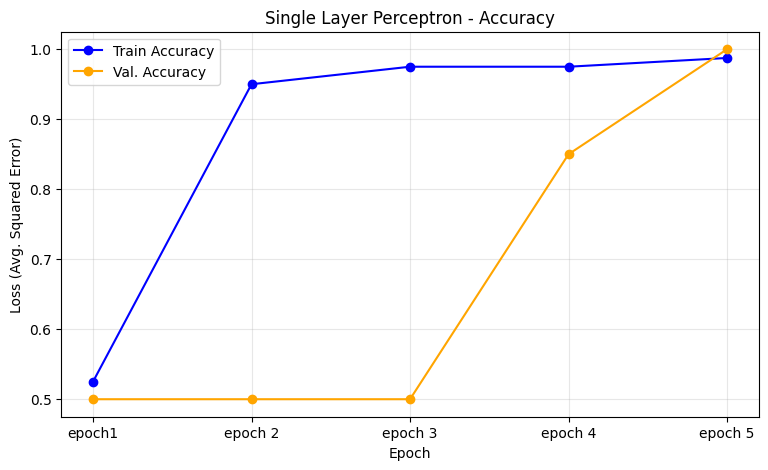

In [ ]:
x = all_metrics["epoch"]
y1 = all_metrics["train_accuracy"]
y2 = all_metrics["val_accuracy"]


# Grafik loss / error function
plt.figure(figsize=(9, 5))
plt.plot(x, y1, label='Train Accuracy', color='blue', marker='o')
plt.plot(x, y2, label='Val. Accuracy', color='orange', marker='o')
plt.title("Single Layer Perceptron - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Loss (Avg. Squared Error)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**Loss (Average Squared Error)**

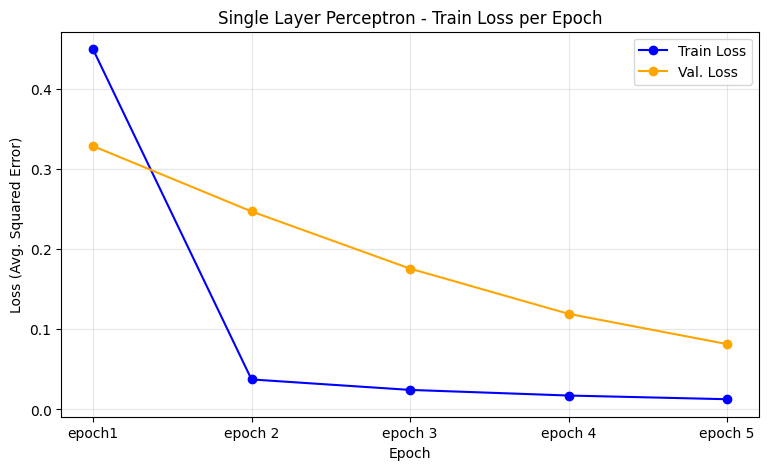

In [ ]:
x_loss = all_metrics["epoch"]
y1_loss = all_metrics["train_avg_squared_error"]
y2_loss = all_metrics["val_avg_squared_error"]
# Grafik loss / error function
plt.figure(figsize=(9, 5))
plt.plot(x_loss, y1_loss, label='Train Loss', color='blue', marker='o')
plt.plot(x_loss, y2_loss, label='Val. Loss', color='orange', marker='o')
plt.title("Single Layer Perceptron - Train Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss (Avg. Squared Error)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**Detail tiap baris**

In [ ]:

display(detail_df.head(10))

# Export hasil perhitungan ke Excel
with pd.ExcelWriter("hasil_manual_slp_python.xlsx", engine="openpyxl") as writer:
    detail_df.to_excel(writer, sheet_name="Detail Training", index=False)
    epoch_metrics.to_excel(writer, sheet_name="Epoch Metrics", index=False)

print("File hasil tersimpan sebagai: hasil_manual_slp_python.xlsx")


,epoch,no,X1,X2,X3,X4,target,bias_before,w1_before,w2_before,...,delta,delta_w1,delta_w2,delta_w3,delta_w4,bias_after,w1_after,w2_after,w3_after,w4_after
0,epoch1,1,5.1,3.5,1.4,0.2,0.0,0.500000,0.500000,0.500000,...,0.007314,0.037303,0.025600,0.010240,0.001463,0.499269,0.496270,0.497440,0.498976,0.499854
1,epoch1,2,4.9,3.0,1.4,0.2,0.0,0.499269,0.496270,0.497440,...,0.010622,0.052047,0.031865,0.014870,0.002124,0.498206,0.491065,0.494253,0.497489,0.499641
2,epoch1,3,4.7,3.2,1.3,0.2,0.0,0.498206,0.491065,0.494253,...,0.011574,0.054400,0.037038,0.015047,0.002315,0.497049,0.485625,0.490550,0.495984,0.499410
3,epoch1,4,4.6,3.1,1.5,0.2,0.0,0.497049,0.485625,0.490550,...,0.012026,0.055321,0.037282,0.018040,0.002405,0.495846,0.480093,0.486821,0.494180,0.499169
4,epoch1,5,5.0,3.6,1.4,0.2,0.0,0.495846,0.480093,0.486821,...,0.008562,0.042811,0.030824,0.011987,0.001712,0.494990,0.475812,0.483739,0.492982,0.498998
5,epoch1,6,5.4,3.9,1.7,0.4,0.0,0.494990,0.475812,0.483739,...,0.004977,0.026874,0.019409,0.008460,0.001991,0.494492,0.473124,0.481798,0.492136,0.498799
6,epoch1,7,4.6,3.4,1.4,0.3,0.0,0.494492,0.473124,0.481798,...,0.011426,0.052560,0.038849,0.015997,0.003428,0.493350,0.467868,0.477913,0.490536,0.498456
7,epoch1,8,5.0,3.4,1.5,0.2,0.0,0.493350,0.467868,0.477913,...,0.009902,0.049512,0.033668,0.014853,0.001980,0.492360,0.462917,0.474546,0.489051,0.498258
8,epoch1,9,4.4,2.9,1.4,0.2,0.0,0.492360,0.462917,0.474546,...,0.017881,0.078678,0.051856,0.025034,0.003576,0.490571,0.455049,0.469361,0.486547,0.497900
9,epoch1,10,4.9,3.1,1.5,0.1,0.0,0.490571,0.455049,0.469361,...,0.013803,0.067635,0.042789,0.020705,0.001380,0.489191,0.448286,0.465082,0.484477,0.497762


File hasil tersimpan sebagai: hasil_manual_slp_python.xlsx
